In [2]:
import pdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pylab as pylab
import cartopy
import cartopy.crs as ccrs
import pickle as pkl
import glob
from metpy import calc
from metpy.units import units
import matplotlib.patches as patches
from scipy import stats

from shared.paths import load_paths
paths = load_paths()

pylab.rcParams['figure.figsize'] = (50., 50.)
%matplotlib inline

In [1]:
cd ../..

/home/users/cornkle/pythonWorkspace/proj_CEH


In [3]:
# da_hist = xr.open_dataset(cnst.network_data+'data/LMCS/MCS_files/CP4_box/mean_09_hist.nc')
# da_fut = xr.open_dataset(cnst.network_data+'data/LMCS/MCS_files/CP4_box/mean_09_fut.nc')

In [4]:
def calc_div(da):
    u = units.Quantity(da['u_srfc'].values, 'm/s')
    v = units.Quantity(da['v_srfc'].values, 'm/s')
    
    dx = units.Quantity(4400, 'm')
    div = calc.divergence(u,v, dx=dx, dy=dx)
    # vort = calc.shearing_deformation(u,v, dx, dx)
    da_div = da['sh'].copy(deep=True)
    da_div.values = div
    
    return da_div

In [5]:
def calc_div10(da):
    u = units.Quantity(da['u10'].values, 'm/s')
    v = units.Quantity(da['v10'].values, 'm/s')
    
    dx = units.Quantity(4400, 'm')
    div = calc.divergence(u,v, dx=dx, dy=dx)
    # vort = calc.shearing_deformation(u,v, dx, dx)
    da_div = da['sh'].copy(deep=True)
    da_div.values = div
    
    return da_div

In [6]:
def vpd_from_t_q_p(temperature, specific_humidity, pressure_hpa):
    """
    Calculate vapor pressure deficit (VPD) from temperature, specific humidity,
    and pressure (given in hPa). Returns VPD in kPa.

    Parameters
    ----------
    temperature : float or array-like
        Air temperature in Kelvin.
    specific_humidity : float or array-like
        Specific humidity (q) in kg/kg.
    pressure_hpa : float or array-like
        Pressure in hPa (hectopascals).

    Returns
    -------
    vpd_kpa : float or array-like
        Vapor pressure deficit in kPa (typical unit).
    """

    # Convert inputs to arrays
    T = np.asarray(temperature)
    q = np.asarray(specific_humidity)

    # Convert pressure from hPa → Pa
    p = np.asarray(pressure_hpa) * 100.0

    # Convert temperature from K to °C
    T_c = T - 273.15

    # Saturation vapor pressure (Pa), Bolton (1980)
    e_s = 611.2 * np.exp(17.67 * T_c / (T_c + 243.5))

    # Actual vapor pressure from specific humidity (Pa)
    e = q * p / (0.622 + 0.378 * q)

    # Vapor pressure deficit (Pa), non-negative
    vpd_pa = np.maximum(e_s - e, 0.0)

    # Convert Pa → kPa
    return vpd_pa / 1000.0

In [7]:
def calc_theta(da):    
    p = units.Quantity(925, 'hPa')
    t = units.Quantity(da['t_srfc'].values+273.15, 'K')
    q = units.Quantity(da['q_srfc'].values/1000, 'kg/kg')
    
    p_up = units.Quantity(650, 'hPa')
    t_up = units.Quantity(da['t_mid'].values+273.15, 'K')
    
    thetaes_up = np.array(calc.saturation_equivalent_potential_temperature(p_up,t_up))
    
    dew = calc.dewpoint_from_specific_humidity(p,t,q)
    thetae_down = np.array(calc.equivalent_potential_temperature(p,t,dew))
     
    thetae = thetae_down #-thetaes_up 
    
    da_theta = da['sh'].copy(deep=True)
    da_theta.values = thetae
    
  #  ipdb.set_trace()
    
    return da_theta

In [8]:
def calc_ef_xarray(da_lh, da_sh, name='EF'):
    """
    Calculate evaporative fraction from 2D or multi-dimensional xarray fields.

    da_lh : latent heat flux, W m-2
    da_sh : sensible heat flux, W m-2

    Returns:
        EF = LH / (LH + SH)

    Works for arrays with dims like:
        y, x
        time, y, x
        storm, y, x
        storm, time, y, x
    """

    denom = da_lh + da_sh

    ef = xr.where(np.isclose(denom, 0) | np.isnan(denom), np.nan, da_lh / denom)

    ef.name = name
    ef.attrs['long_name'] = 'evaporative fraction'
    ef.attrs['units'] = '1'

    return ef

In [9]:
def add_ef_abs_and_anom_xarray(ds_abs, ds_anom):
    """
    Add EF to storm-day absolute and anomaly xarray datasets.

    ds_abs  : storm-day absolute dataset
    ds_anom : storm-day anomaly dataset

    Adds:
        ef_1deg to ds_abs
        ef_1deg to ds_anom

    EF anomaly is calculated as:
        EF_abs - EF_clim

    not from LH_anom / (LH_anom + SH_anom).
    """

    lhvar = 'lh'
    shvar = 'sh'
    outvar = 'ef'

    ef_abs = calc_ef_xarray(ds_abs[lhvar], ds_abs[shvar], name=outvar)

    lh_clim = ds_abs[lhvar] - ds_anom[lhvar]
    sh_clim = ds_abs[shvar] - ds_anom[shvar]

    ef_clim = calc_ef_xarray(lh_clim, sh_clim, name=outvar)

    ds_abs[outvar] = ef_abs
    ds_anom[outvar] = ef_abs - ef_clim

    ds_anom[outvar].attrs['long_name'] = 'evaporative fraction anomaly'
    ds_anom[outvar].attrs['units'] = '1'

    return ds_abs, ds_anom

In [10]:
def calc_thetae_xarray(da_t, da_q, p_hpa=925., name='thetae'):
    """
    Calculate equivalent potential temperature from T and q.

    da_t  : temperature, K or degC
    da_q  : specific humidity, kg/kg or g/kg
    p_hpa : pressure in hPa, scalar or DataArray

    Returns theta-e in K.

    Uses a Bolton-style approximation.
    """

    t = da_t.astype(float)
    q = da_q.astype(float)

    # convert q from g/kg to kg/kg if needed
    q = xr.where(q > 0.1, q / 1000., q)

    # convert T from Celsius to Kelvin if needed
    t_k = xr.where(t < 150, t + 273.15, t)

    # mixing ratio, kg/kg
    r = q / (1 - q)

    # vapour pressure, hPa
    eps = 0.622
    e = (q * p_hpa) / (eps + (1 - eps) * q)

    # dewpoint temperature, K
    # Bolton inversion from vapour pressure
    ln_ratio = np.log(e / 6.112)
    td_c = (243.5 * ln_ratio) / (17.67 - ln_ratio)
    td_k = td_c + 273.15

    # LCL temperature, K; Bolton 1980 approximation
    tlcl = 1. / (1. / (td_k - 56.) + np.log(t_k / td_k) / 800.) + 56.

    # potential temperature, K
    rd_cp = 0.2854
    theta = t_k * (1000. / p_hpa) ** rd_cp

    # equivalent potential temperature, K
    thetae = theta * np.exp((3376. / tlcl - 2.54) * r * (1. + 0.81 * r))

    thetae.name = name
    thetae.attrs['units'] = 'K'
    thetae.attrs['long_name'] = 'equivalent potential temperature'

    return thetae

In [11]:
def add_thetae_abs_and_anom_xarray(ds_abs, ds_anom, suffix='1deg', p_hpa=1000.):
    """
    Add theta-e to storm-day absolute and anomaly xarray datasets.

    ds_abs  : storm-day absolute dataset
    ds_anom : storm-day anomaly dataset

    Adds:
        thetae_calc_1deg to ds_abs
        thetae_calc_1deg to ds_anom

    Theta-e anomaly is:
        thetae_abs - thetae_clim

    not thetae(T_anom, q_anom).
    """

    tvar = f't_srfc'
    qvar = f'q_srfc'
    outvar = f'thetae'

    # storm-day absolute theta-e
    thetae_abs = calc_thetae_xarray(ds_abs[tvar], ds_abs[qvar], p_hpa=p_hpa, name=outvar)

    # reconstruct climatological T/q for the same period
    t_clim = ds_abs[tvar] - ds_anom[tvar]
    q_clim = ds_abs[qvar] - ds_anom[qvar]

    # climatological theta-e
    thetae_clim = calc_thetae_xarray(t_clim, q_clim, p_hpa=p_hpa, name=outvar)

    # store absolute and anomaly
    ds_abs[outvar] = thetae_abs
    ds_anom[outvar] = thetae_abs - thetae_clim

    ds_anom[outvar].attrs['units'] = 'K'
    ds_anom[outvar].attrs['long_name'] = 'equivalent potential temperature anomaly'

    return ds_abs, ds_anom

In [12]:
import numpy as np
import xarray as xr

def saturation_vapour_pressure_hpa(t_k):
    """
    Saturation vapour pressure over liquid water, hPa.
    Input temperature in K.
    """
    t_c = t_k - 273.15
    return 6.112 * np.exp((17.67 * t_c) / (t_c + 243.5))


def calc_thetae_xarray(da_t, da_q, p_hpa=925., name='thetae'):
    """
    Equivalent potential temperature from T and specific humidity.

    da_t  : temperature, K or degC
    da_q  : specific humidity, kg/kg or g/kg
    p_hpa : pressure in hPa

    Returns theta-e in K.
    """

    t = da_t.astype(float)
    q = da_q.astype(float)

    # q: g/kg -> kg/kg if needed
    q = xr.where(q > 0.1, q / 1000., q)

    # T: degC -> K if needed
    t_k = xr.where(t < 150, t + 273.15, t)

    # mixing ratio, kg/kg
    r = q / (1 - q)

    # vapour pressure, hPa
    eps = 0.622
    e = (q * p_hpa) / (eps + (1 - eps) * q)
    e = xr.where(e <= 0, np.nan, e)

    # dewpoint from vapour pressure, K
    ln_ratio = np.log(e / 6.112)
    td_c = (243.5 * ln_ratio) / (17.67 - ln_ratio)
    td_k = td_c + 273.15

    # LCL temperature, K; Bolton approximation
    tlcl = 1. / (1. / (td_k - 56.) + np.log(t_k / td_k) / 800.) + 56.

    # potential temperature
    rd_cp = 0.2854
    theta = t_k * (1000. / p_hpa) ** rd_cp

    # equivalent potential temperature
    thetae = theta * np.exp((3376. / tlcl - 2.54) * r * (1. + 0.81 * r))

    thetae.name = name
    thetae.attrs['units'] = 'K'
    thetae.attrs['long_name'] = 'equivalent potential temperature'

    return thetae


def calc_thetaes_xarray(da_t, p_hpa=650., name='thetaes'):
    """
    Saturated equivalent potential temperature from T and pressure.

    da_t  : temperature, K or degC
    p_hpa : pressure in hPa

    Returns saturated theta-e in K.
    """

    t = da_t.astype(float)
    t_k = xr.where(t < 150, t + 273.15, t)

    eps = 0.622

    # saturation vapour pressure, hPa
    es = saturation_vapour_pressure_hpa(t_k)

    # avoid nonsense when es approaches p
    es = xr.where(es >= 0.99 * p_hpa, np.nan, es)

    # saturation mixing ratio, kg/kg
    rs = eps * es / (p_hpa - es)

    # for saturated air, dewpoint = temperature and LCL ~= T
    tlcl = t_k

    rd_cp = 0.2854
    theta = t_k * (1000. / p_hpa) ** rd_cp

    thetaes = theta * np.exp((3376. / tlcl - 2.54) * rs * (1. + 0.81 * rs))

    thetaes.name = name
    thetaes.attrs['units'] = 'K'
    thetaes.attrs['long_name'] = 'saturated equivalent potential temperature'

    return thetaes

In [13]:
def add_cape_proxy_abs_and_anom_xarray(ds_abs, ds_anom,
                                       p_srfc_hpa=925., p_mid_hpa=650.):
    """
    Add a two-level CAPE proxy:

        cape_proxy_calc = thetae_srfc - thetaes_mid

    where:
        thetae_srfc  = thetae(T_srfc, q_srfc, 925 hPa)
        thetaes_mid  = saturated thetae(T_mid, 650 hPa)

    The anomaly is calculated as:

        cape_proxy_abs - cape_proxy_clim

    not from anomaly T/q directly.
    """

    t_s_var = f't_srfc'
    q_s_var = f'q_srfc'
    t_m_var = f't_mid'

    thetae_var = f'thetae'
    thetaes_var = f'thetaes_mid'
    cape_var = f'cape_prox'

    # storm-day absolute fields
    thetae_s_abs = calc_thetae_xarray(ds_abs[t_s_var], ds_abs[q_s_var],
                                      p_hpa=p_srfc_hpa, name=thetae_var)

    thetaes_m_abs = calc_thetaes_xarray(ds_abs[t_m_var],
                                        p_hpa=p_mid_hpa, name=thetaes_var)

    cape_abs = thetae_s_abs - thetaes_m_abs
    cape_abs.name = cape_var
    cape_abs.attrs['units'] = 'K'
    cape_abs.attrs['long_name'] = r'two-level CAPE proxy: thetae_srfc - thetaes_mid'

    # reconstruct climatological fields
    t_s_clim = ds_abs[t_s_var] - ds_anom[t_s_var]
    q_s_clim = ds_abs[q_s_var] - ds_anom[q_s_var]
    t_m_clim = ds_abs[t_m_var] - ds_anom[t_m_var]

    # climatological proxy
    thetae_s_clim = calc_thetae_xarray(t_s_clim, q_s_clim,
                                       p_hpa=p_srfc_hpa, name=thetae_var)

    thetaes_m_clim = calc_thetaes_xarray(t_m_clim,
                                         p_hpa=p_mid_hpa, name=thetaes_var)

    cape_clim = thetae_s_clim - thetaes_m_clim

    # store absolute and anomaly fields
    ds_abs[thetae_var] = thetae_s_abs
    ds_abs[thetaes_var] = thetaes_m_abs
    ds_abs[cape_var] = cape_abs

    ds_anom[thetae_var] = thetae_s_abs - thetae_s_clim
    ds_anom[thetaes_var] = thetaes_m_abs - thetaes_m_clim
    ds_anom[cape_var] = cape_abs - cape_clim

    ds_anom[thetae_var].attrs['units'] = 'K'
    ds_anom[thetaes_var].attrs['units'] = 'K'
    ds_anom[cape_var].attrs['units'] = 'K'

    ds_anom[cape_var].attrs['long_name'] = (
        r'two-level CAPE proxy anomaly: '
        r'(thetae_srfc - thetaes_mid)_storm - '
        r'(thetae_srfc - thetaes_mid)_clim'
    )

    return ds_abs, ds_anom

In [14]:
cp4_path = '/gws/ssde/j25b/lmcs/cklein/CP_models/MCS_files/WAf/CP4_box_JASMIN/mean3h_v2'

In [15]:
da_hist_anom = (xr.open_dataset(cp4_path + '/hist_anom_Jul-Sep_17h_2d.nc')+xr.open_dataset(cp4_path + '/hist_anom_Jul-Sep_18h_2d.nc'))/2
da_fut_anom = (xr.open_dataset(cp4_path + '/fut_anom_Jul-Sep_17h_2d.nc')+xr.open_dataset(cp4_path + '/fut_anom_Jul-Sep_18h_2d.nc'))/2

da_hist = (xr.open_dataset(cp4_path + '/hist_mean_Jul-Sep_17h_2d.nc')+xr.open_dataset(cp4_path + '/hist_mean_Jul-Sep_18h_2d.nc'))/2
da_fut = (xr.open_dataset(cp4_path + '/fut_mean_Jul-Sep_17h_2d.nc')+xr.open_dataset(cp4_path + '/fut_mean_Jul-Sep_18h_2d.nc'))/2

In [33]:
h = '17'
da_hist = xr.open_dataset(cp4_path + '/hist_mean_Jul-Sep_'+h+'h_2d.nc')
da_fut = xr.open_dataset(cp4_path + '/fut_mean_Jul-Sep_'+h+'h_2d.nc')
da_hist_anom = xr.open_dataset(cp4_path + '/hist_anom_Jul-Sep_'+h+'h_2d.nc')
da_fut_anom = xr.open_dataset(cp4_path + '/fut_anom_Jul-Sep_'+h+'h_2d.nc')

In [34]:
clim_hist = da_hist-da_hist_anom
clim_fut = da_fut-da_fut_anom

In [35]:
da_hist, da_hist_anom = add_ef_abs_and_anom_xarray(da_hist, da_hist_anom)
da_fut,  da_fut_anom  = add_ef_abs_and_anom_xarray(da_fut,  da_fut_anom)

In [36]:
da_hist, da_hist_anom = add_thetae_abs_and_anom_xarray(da_hist, da_hist_anom, p_hpa=925.)
da_fut,  da_fut_anom  = add_thetae_abs_and_anom_xarray(da_fut,  da_fut_anom,  p_hpa=925.)

In [37]:
da_hist, da_hist_anom = add_cape_proxy_abs_and_anom_xarray(
    da_hist, da_hist_anom, p_srfc_hpa=925., p_mid_hpa=650.)

da_fut, da_fut_anom = add_cape_proxy_abs_and_anom_xarray(
    da_fut, da_fut_anom, p_srfc_hpa=925., p_mid_hpa=650.)

In [38]:
da_hist['t_srfc'].max()

<xarray.DataArray 't_srfc' ()> Size: 8B
array(300.79373169)

In [39]:
list(da_hist.keys())

['lw_out_PBLtop',
 'lsRain',
 'tcwv',
 'sh',
 'lh',
 't2',
 'q2',
 'pblH',
 'shear',
 'u_mid',
 'u_srfc',
 'v_mid',
 'v_srfc',
 'q_mid',
 't_mid',
 't_srfc',
 'q_srfc',
 'geoH_srfc',
 'lsRain_noon',
 'lwout_noon',
 'SM',
 'lw_net',
 'sw_in',
 'sw_net',
 'u10',
 'v10',
 'ef',
 'thetae',
 'thetaes_mid',
 'cape_prox']

<>:135: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:136: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:166: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:167: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:195: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:135: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:136: SyntaxWarning: "\D" is an invalid escape sequence. Such sequen

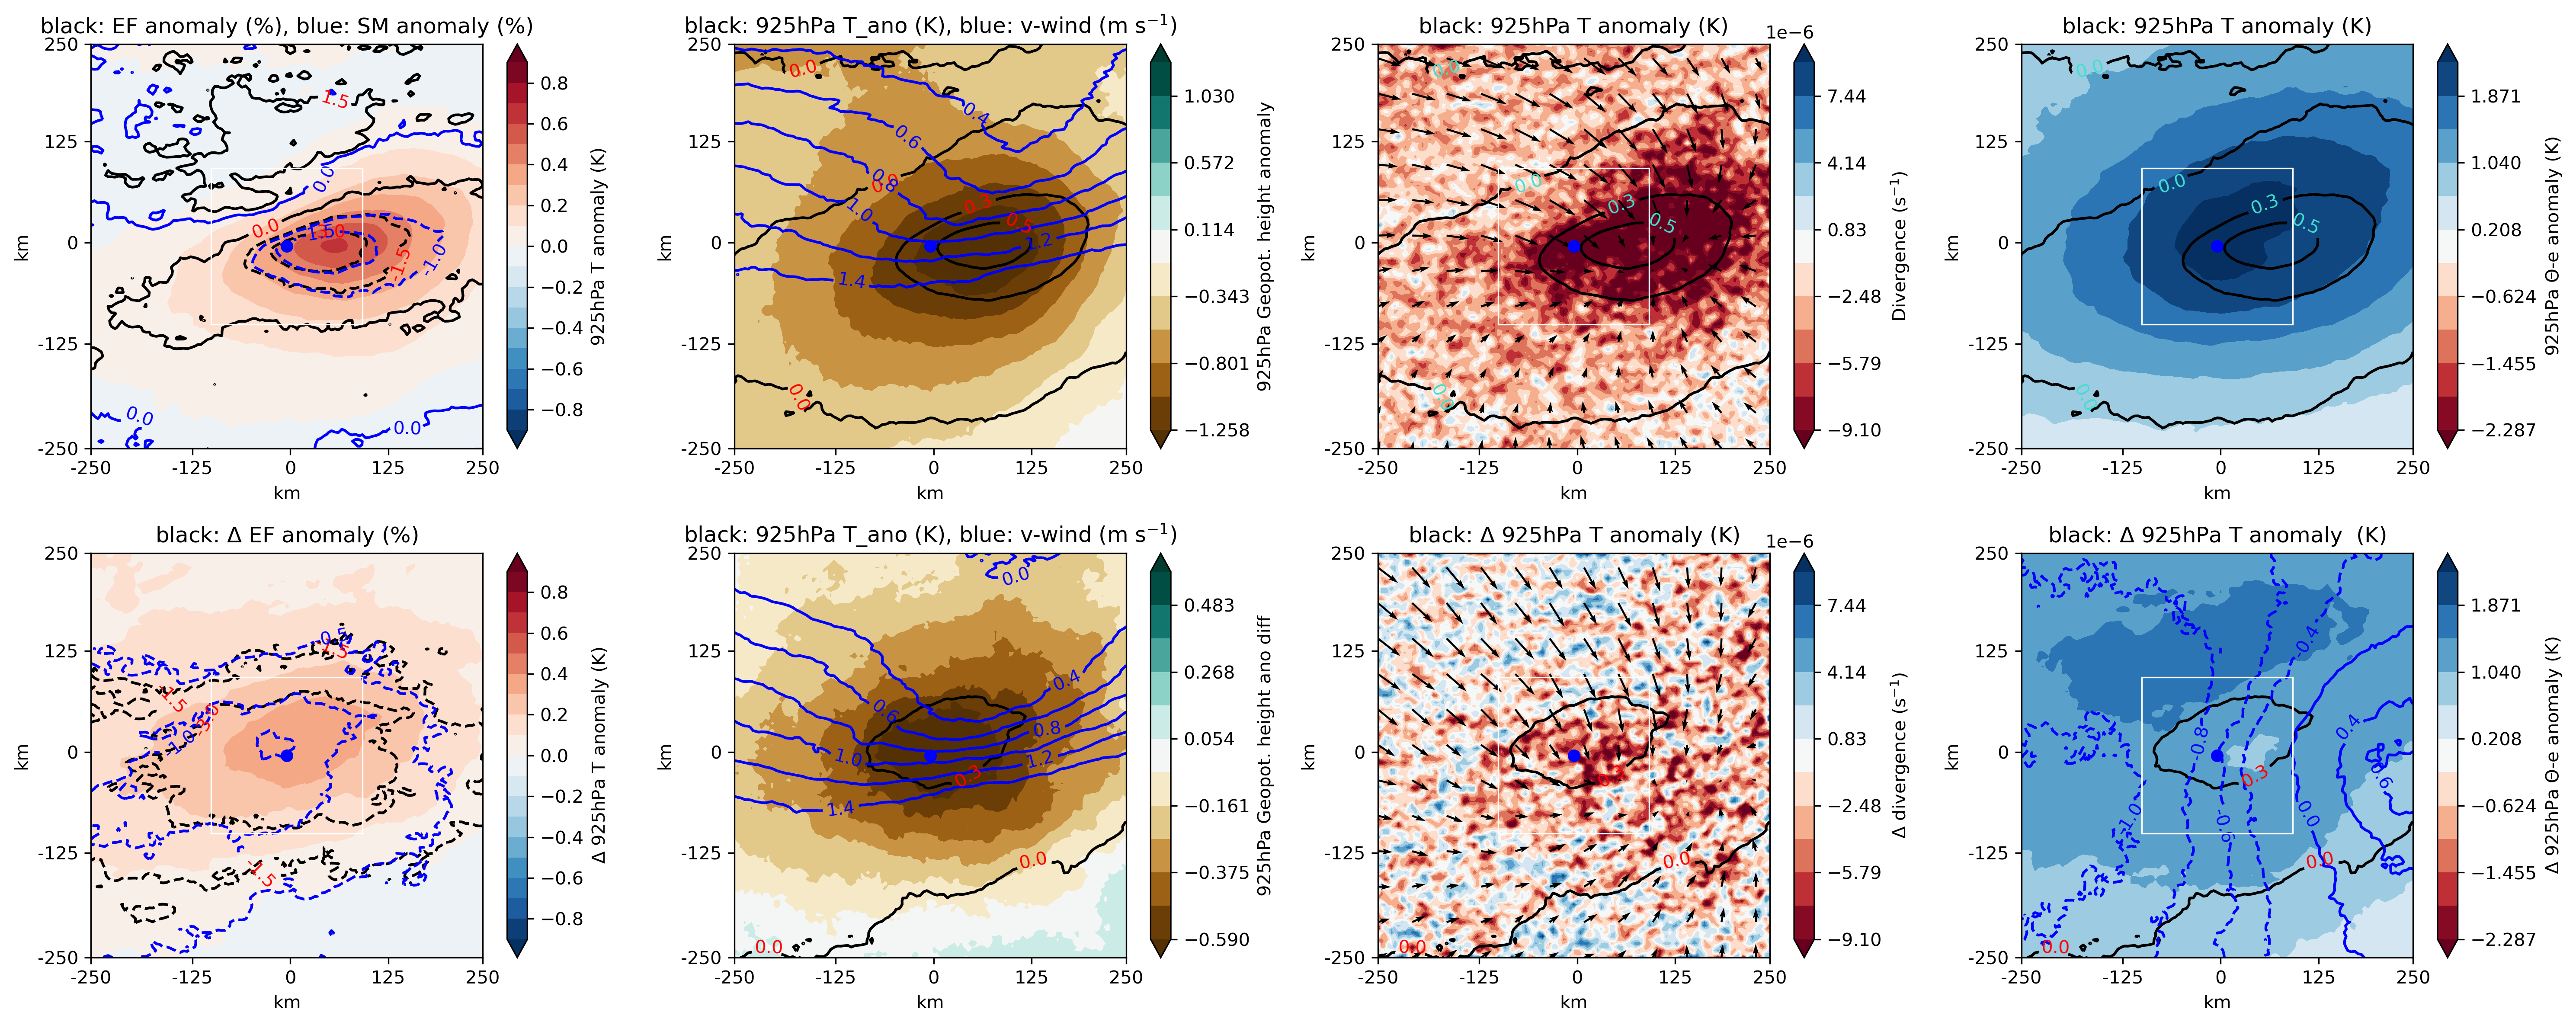

In [40]:
f = plt.figure(figsize=(20,8), dpi=300)
mname = 'node'
extent = 57 #* 4.4

ticks = np.array([0,58-57/2,58,58+57/2,114])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]
mid=57
dist = 22
box = [mid-dist, mid+dist,mid-dist, mid+dist]

ax = f.add_subplot(2,4,1)

#ano = da_hist_anom['t2']#.mean('cases')
cont =da_hist_anom['ef']*100
cont2 = da_hist_anom['SM']
ano = da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='925hPa T anomaly (K)')
plt.title('black: EF anomaly (%), blue: SM anomaly (%)')
cm = ax.contour(cont, colors='k', levels=[-3,-1.5,0,1.5,3], linewidths=1.5)  #
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cm = ax.contour(cont2, colors='blue', levels=[-1.5,-1,0,1,1.5], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='blue')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

ax = f.add_subplot(2,4,3)
ano_div = calc_div(da_hist)
cont = da_hist_anom['t_srfc']


thresh = np.max(np.abs(np.percentile(ano_div, [10, 90])))

plt.contourf(ano_div, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='Divergence (s$^{-1}$)')
plt.title('black: 925hPa T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_hist_anom['u_srfc'].values, da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,4,4)
ano = da_hist_anom['thetae']#-da_hist_anom['t_srfc']
cont = da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'925hPa $\Theta$-e anomaly (K)')
plt.title('black: 925hPa T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

cont = da_hist['u_mid']
cm = ax.contour(cont, colors='b', levels=[-5,-1.4,-1.2,-1, -0.8, -0.6,-0.4,0,0.4,0.6,0.8,1,1.2,1.4,5], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='b')


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,4,2)
ano = da_hist_anom['geoH_srfc']#*10
cont = da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='BrBG', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'925hPa Geopot. height anomaly')
plt.title('black: 925hPa T_ano (K), blue: v-wind (m s$^{-1}$)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cont = da_hist['v_srfc']
cm = ax.contour(cont, colors='b', levels=[-1.4,-1.2,-1, -0.8, -0.6,-0.4,0,0.4,0.6,0.8,1,1.2,1.4], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='b')

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



###############################################

ax = f.add_subplot(2,4,5)

#ano = da_hist_anom['t2']#.mean('cases')
cont =(da_fut_anom['ef']-da_hist_anom['ef'])*100
cont2 = da_fut_anom['SM']-da_hist_anom['SM']

ano = da_fut_anom['t_srfc']-da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1))  #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='$\Delta$ 925hPa T anomaly (K)')
plt.title('black: $\Delta$ EF anomaly (%)')
cm = ax.contour(cont, colors='k', levels=[-3,-1.5], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cm = ax.contour(cont2, colors='blue', levels=[-1.5,-1,-0.5], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='blue')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,4,7)

ano = calc_div(da_hist)
anofut = calc_div(da_fut)
ano = anofut-ano
cont = da_fut_anom['t_srfc']-da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano_div, [10, 90])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='$\Delta$ divergence (s$^{-1}$)')
plt.title('black: $\Delta$ 925hPa T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9,-0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_fut_anom['u_srfc'].values-da_hist_anom['u_srfc'].values, da_fut_anom['v_srfc'].values-da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,4,8)
pano = da_hist_anom['thetae']
ano = (da_fut_anom['thetae']-da_hist_anom['thetae'])
cont = da_fut_anom['t_srfc']-da_hist_anom['t_srfc']

qthresh = np.max(np.abs(np.percentile(pano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(qthresh * -1, qthresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'$\Delta$ 925hPa $\Theta$-e anomaly (K)')
plt.title('black: $\Delta$ 925hPa T anomaly  (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)

cont = da_fut_anom['shear']
cm = ax.contour(cont, colors='b', levels=[-1.4,-1.2,-1, -0.8, -0.6,-0.4,0,0.4,0.6,0.8,1,1.2,1.4], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='b')
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



ax = f.add_subplot(2,4,6)
ano =  (da_fut_anom['geoH_srfc']-da_hist_anom['geoH_srfc'])
cont = (da_fut_anom['t_srfc']-da_hist_anom['t_srfc'])

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='BrBG', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'925hPa Geopot. height ano diff')
plt.title('black: 925hPa T_ano (K), blue: v-wind (m s$^{-1}$)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cont = da_fut['v_srfc']
cm = ax.contour(cont, colors='b', levels=[-1.4,-1.2,-1, -0.8, -0.6,-0.4,0,0.4,0.6,0.8,1,1.2,1.4], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='b')

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



plt.tight_layout()
f.savefig('cp4_2d_18h_gig1.jpg')

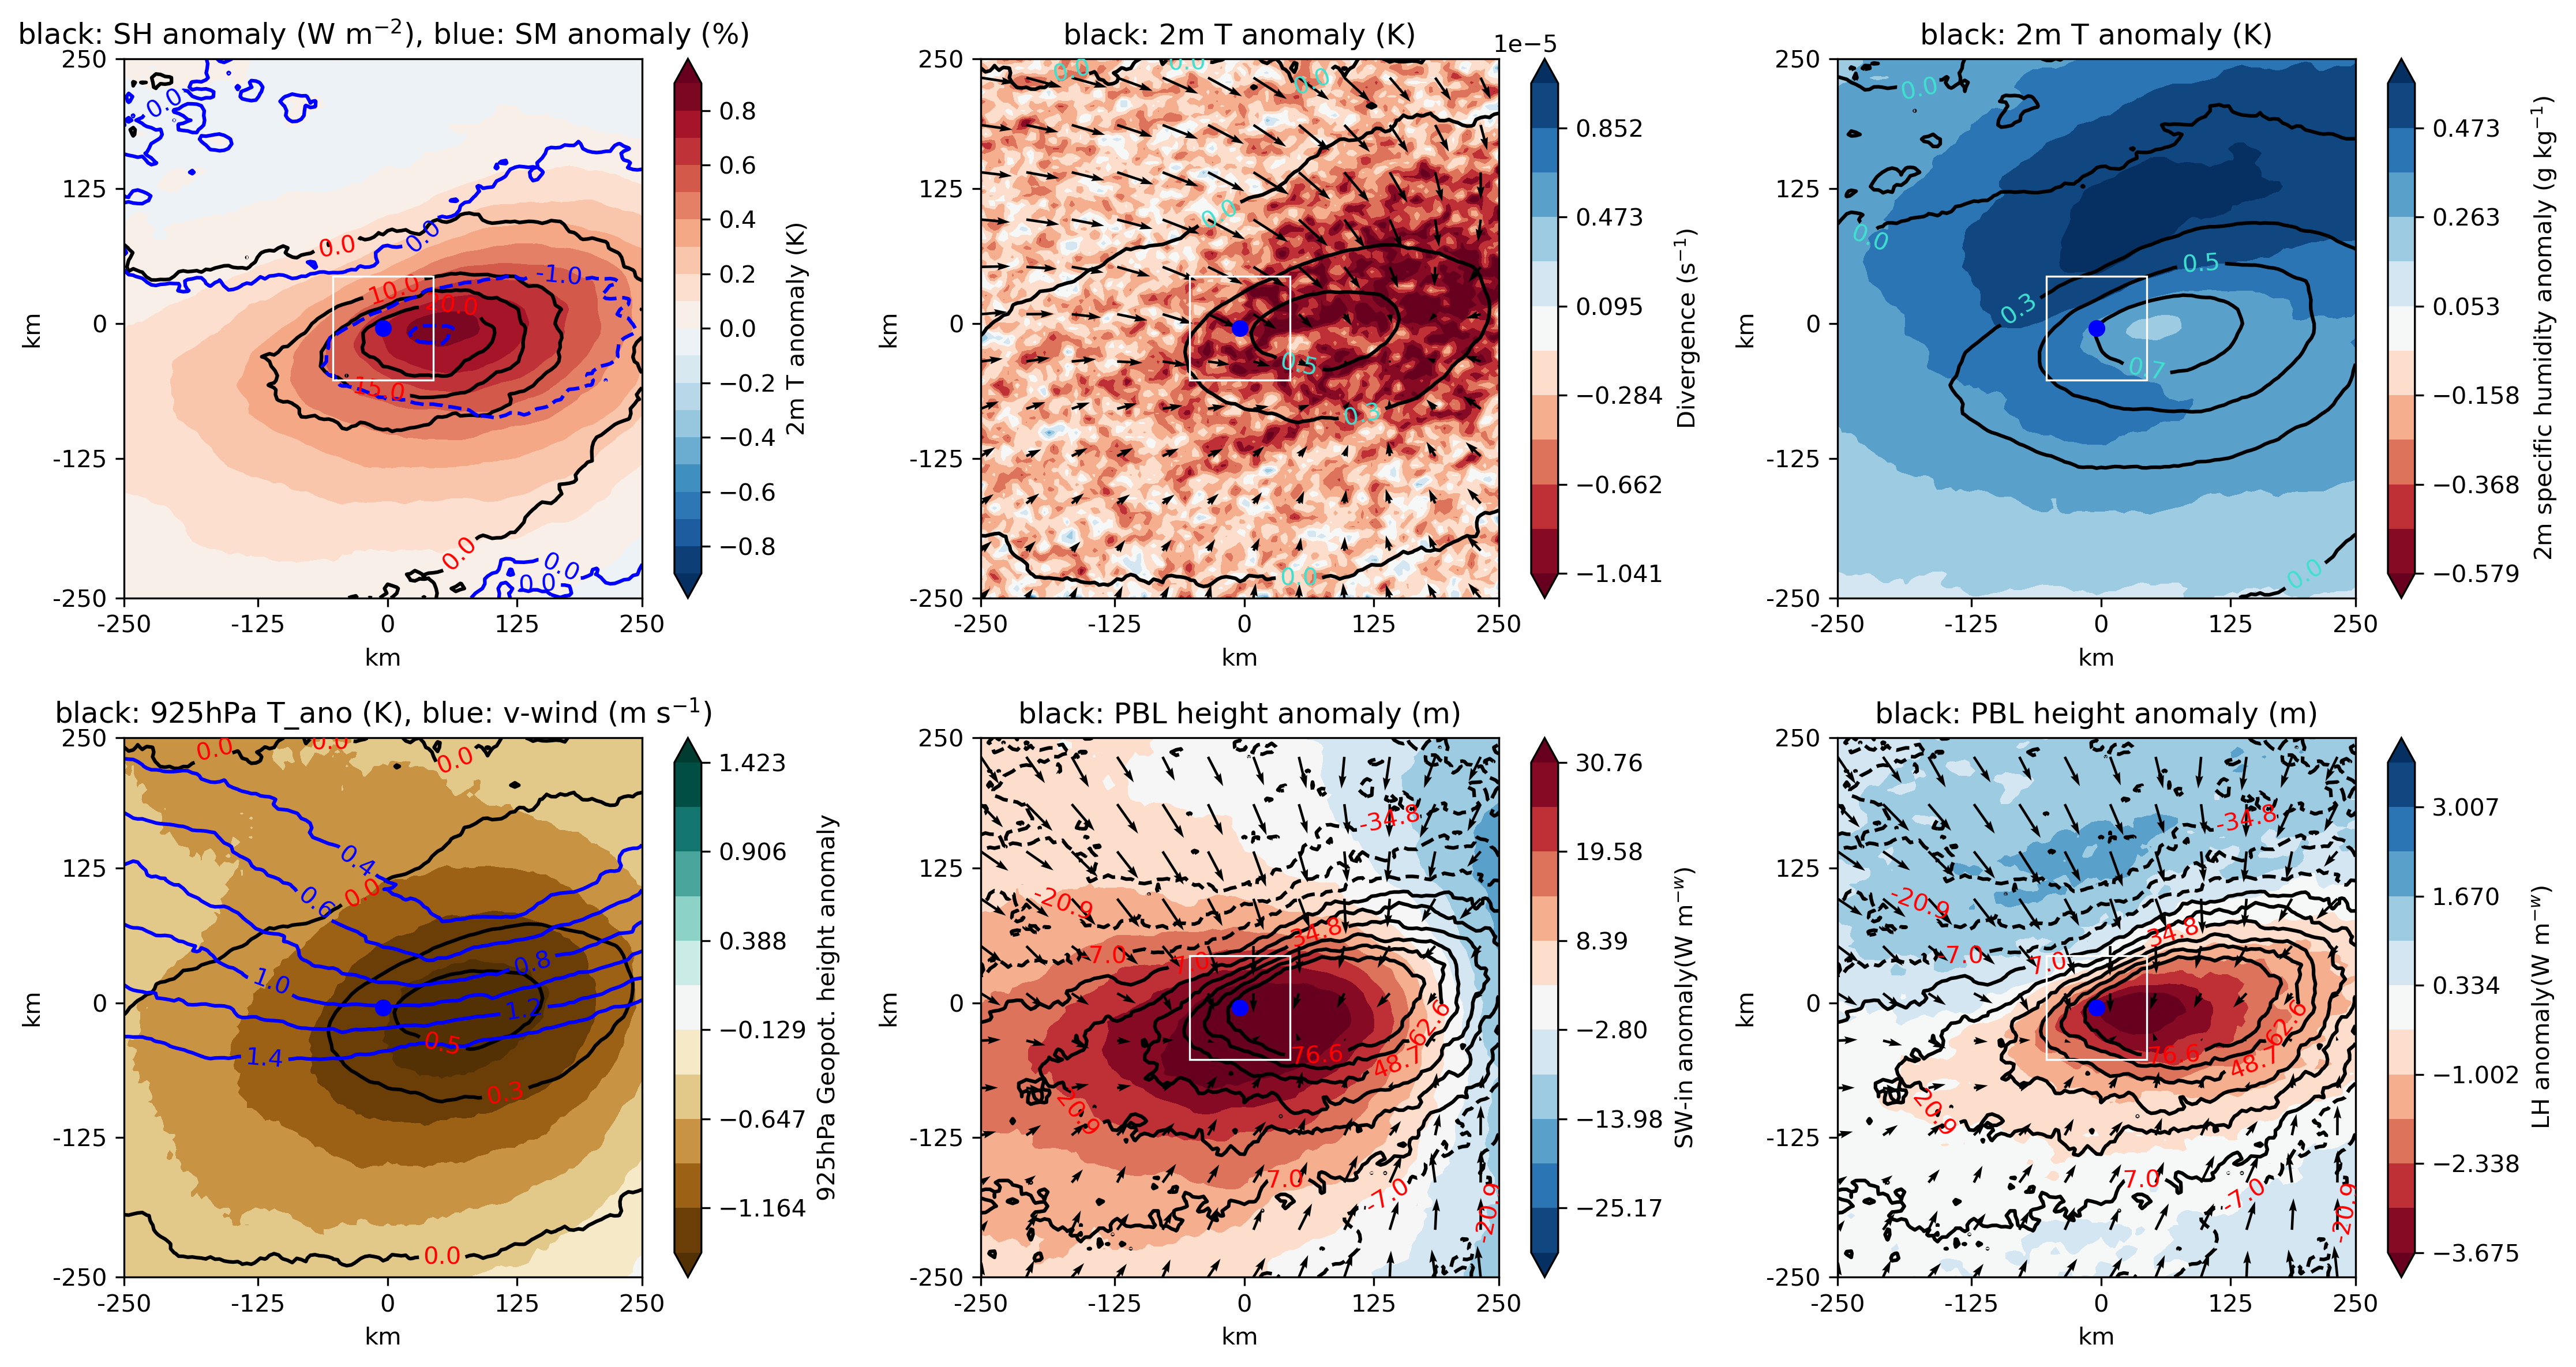

In [57]:
f = plt.figure(figsize=(15,8), dpi=300)
mname = 'node'
extent = 57 #* 4.4

ticks = np.array([0,58-57/2,58,58+57/2,114])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]
mid=57
dist = 11
box = [mid-dist, mid+dist,mid-dist, mid+dist]

ax = f.add_subplot(2,3,1)

#ano = da_hist_anom['t2']#.mean('cases')
cont =da_hist_anom['sh']
cont2 = da_hist_anom['SM']
ano = da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='2m T anomaly (K)')
plt.title('black: SH anomaly (W m$^{-2}$), blue: SM anomaly (%)')
cm = ax.contour(cont, colors='k', levels=[-20,-15,-10,0,10,15,20], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='blue')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

ax = f.add_subplot(2,3,2)
ano_div = calc_div(da_hist)
cont = da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano_div, [5, 95])))

plt.contourf(ano_div, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='Divergence (s$^{-1}$)')
plt.title('black: 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_hist_anom['u_srfc'].values, da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,3)
ano = da_hist_anom['q2']*1000
cont = da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'2m specific humidity anomaly (g kg$^{-1}$)')
plt.title('black: 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



###############################################

ax = f.add_subplot(2,3,4)
ano = da_hist_anom['geoH_srfc']#*10
cont = da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='BrBG', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'925hPa Geopot. height anomaly')
plt.title('black: 925hPa T_ano (K), blue: v-wind (m s$^{-1}$)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cont = da_fut['v_srfc']
cm = ax.contour(cont, colors='b', levels=[-1.4,-1.2,-1, -0.8, -0.6,-0.4,0,0.4,0.6,0.8,1,1.2,1.4], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='b')

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,5)

ano = da_hist_anom['sw_net']
cont = da_hist_anom['pblH']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))
thresh_cont = np.max(np.abs(np.percentile(cont, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='SW-in anomaly(W m$^{-w}$)')
plt.title('black: PBL height anomaly (m)')
cm = ax.contour(cont, colors='k', levels=np.linspace(thresh_cont * -1, thresh_cont, 12), linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_fut_anom['u_srfc'].values-da_hist_anom['u_srfc'].values, da_fut_anom['v_srfc'].values-da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,6)

ano = da_hist_anom['ef']*100
cont = da_hist_anom['pblH']

thresh = np.max(np.abs(np.percentile(ano, [1, 99])))
thresh_cont = np.max(np.abs(np.percentile(cont, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='LH anomaly(W m$^{-w}$)')
plt.title('black: PBL height anomaly (m)')
cm = ax.contour(cont, colors='k', levels=np.linspace(thresh_cont * -1, thresh_cont, 12), linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_fut_anom['u_srfc'].values-da_hist_anom['u_srfc'].values, da_fut_anom['v_srfc'].values-da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


plt.tight_layout()
#f.savefig('cp4_2d_18h_histOnly.jpg')

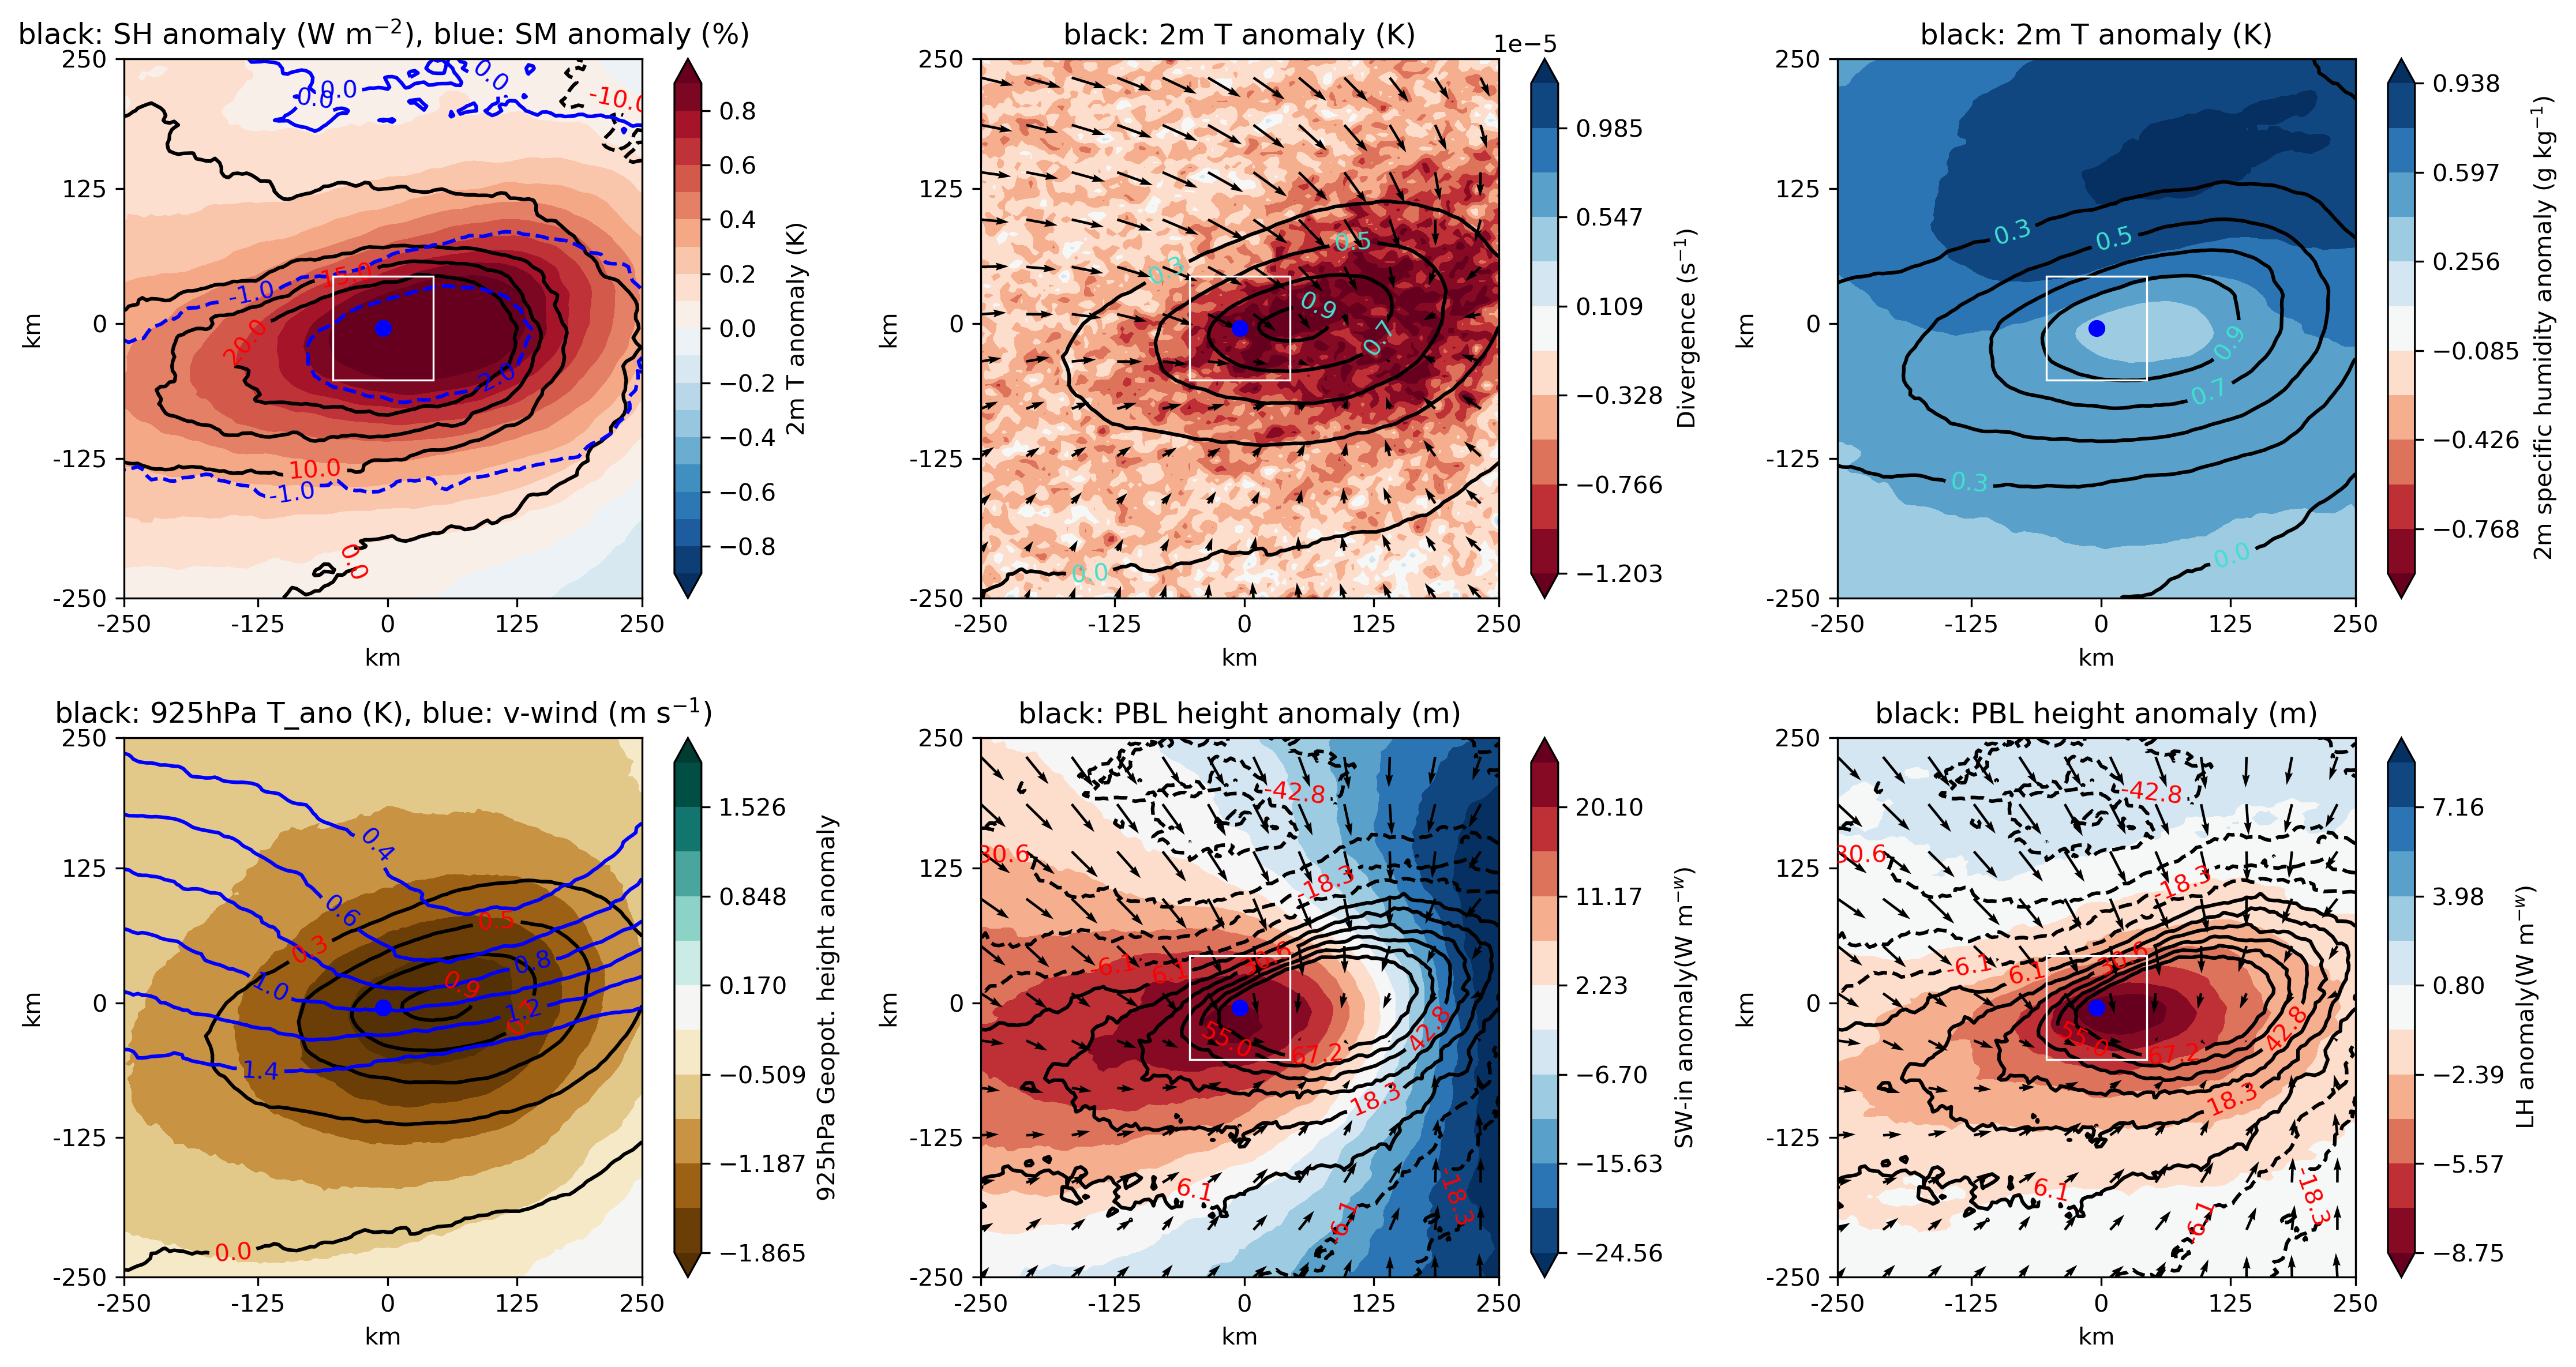

In [49]:
f = plt.figure(figsize=(15,8), dpi=300)
mname = 'node'
extent = 57 #* 4.4

ticks = np.array([0,58-57/2,58,58+57/2,114])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]
mid=57
dist = 11
box = [mid-dist, mid+dist,mid-dist, mid+dist]

ax = f.add_subplot(2,3,1)

#ano = da_hist_anom['t2']#.mean('cases')
cont =da_fut_anom['sh']
cont2 = da_fut_anom['SM']
ano = da_fut_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='2m T anomaly (K)')
plt.title('black: SH anomaly (W m$^{-2}$), blue: SM anomaly (%)')
cm = ax.contour(cont, colors='k', levels=[-20,-15,-10,0,10,15,20], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='blue')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

ax = f.add_subplot(2,3,2)
ano_div = calc_div(da_fut)
cont = da_fut_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano_div, [5, 95])))

plt.contourf(ano_div, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='Divergence (s$^{-1}$)')
plt.title('black: 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_hist_anom['u_srfc'].values, da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,3)
ano = da_fut_anom['q2']*1000
cont = da_fut_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'2m specific humidity anomaly (g kg$^{-1}$)')
plt.title('black: 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



###############################################

ax = f.add_subplot(2,3,4)
ano = da_fut_anom['geoH_srfc']#*10
cont = da_fut_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='BrBG', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'925hPa Geopot. height anomaly')
plt.title('black: 925hPa T_ano (K), blue: v-wind (m s$^{-1}$)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cont = da_fut['v_srfc']
cm = ax.contour(cont, colors='b', levels=[-1.4,-1.2,-1, -0.8, -0.6,-0.4,0,0.4,0.6,0.8,1,1.2,1.4], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='b')

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,5)

ano = da_fut_anom['sw_net']
cont = da_hist_anom['pblH']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))
thresh_cont = np.max(np.abs(np.percentile(cont, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='SW-in anomaly(W m$^{-w}$)')
plt.title('black: PBL height anomaly (m)')
cm = ax.contour(cont, colors='k', levels=np.linspace(thresh_cont * -1, thresh_cont, 12), linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_fut_anom['u_srfc'].values-da_hist_anom['u_srfc'].values, da_fut_anom['v_srfc'].values-da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,6)

ano = da_fut_anom['ef']*100
cont = da_hist_anom['pblH']

thresh = np.max(np.abs(np.percentile(ano, [1, 99])))
thresh_cont = np.max(np.abs(np.percentile(cont, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='LH anomaly(W m$^{-w}$)')
plt.title('black: PBL height anomaly (m)')
cm = ax.contour(cont, colors='k', levels=np.linspace(thresh_cont * -1, thresh_cont, 12), linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_fut_anom['u_srfc'].values-da_hist_anom['u_srfc'].values, da_fut_anom['v_srfc'].values-da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


plt.tight_layout()